# COVID Political Classification Checkpoint Trajectory

Plots how checkpoint performance changes over training step for the COVID-only, UKR-only, and COVID+UKR merged neighbor-matching models.

Eval setting: `covid_political`, classification (`pl`), 3-shot, test split.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")

CSV_PATH = Path("eval_results.csv")
if not CSV_PATH.exists():
    CSV_PATH = Path("scripts/plotting/covid_political_pl_trajectory/eval_results.csv")
CSV_PATH = CSV_PATH.resolve()

SPLIT = "test"
METRICS = ["accuracy", "f1", "roc_auc"]
TRAINING_ORDER = ["covid_only", "ukr_only", "merged_covid_ukr"]
TRAINING_LABELS = {
    "covid_only": "COVID-only",
    "ukr_only": "UKR-only",
    "merged_covid_ukr": "COVID+UKR merged",
}
REQUESTED_STEPS = [0, 1000, 2000, 3000, 5000, 10000, 25000, 50000, 75000, 100000]

In [2]:
df = pd.read_csv(CSV_PATH)
for col in METRICS:
    df[col] = pd.to_numeric(df[col], errors="coerce")
df["shots"] = df["shots"].astype(int)

df["step"] = df["model"].str.extract(r"_step([0-9]+)$", expand=False).astype(int)
df["training_graph"] = df["model"].str.extract(
    r"^(covid_only_nm|ukr_only_nm|merged_ukr_rus_covid_nm)", expand=False
)
df["training_graph"] = df["training_graph"].map({
    "covid_only_nm": "covid_only",
    "ukr_only_nm": "ukr_only",
    "merged_ukr_rus_covid_nm": "merged_covid_ukr",
})
df["training_label"] = df["training_graph"].map(TRAINING_LABELS)

if set(df["dataset"]) != {"covid_political"}:
    raise ValueError(f"Unexpected datasets: {sorted(set(df['dataset']))}")
if set(df["task"]) != {"pl"}:
    raise ValueError(f"Unexpected tasks: {sorted(set(df['task']))}")
if set(df["shots"]) != {3}:
    raise ValueError(f"Unexpected shots: {sorted(set(df['shots']))}")
if set(df["split"]) != {SPLIT}:
    raise ValueError(f"Unexpected splits: {sorted(set(df['split']))}")
if set(df["training_graph"]) != set(TRAINING_ORDER):
    raise ValueError(f"Unexpected training graphs: {sorted(set(df['training_graph']))}")

df["training_graph"] = pd.Categorical(df["training_graph"], categories=TRAINING_ORDER, ordered=True)
df = df.sort_values(["training_graph", "step"])

present_steps = sorted(df["step"].unique())
missing_steps = sorted(set(REQUESTED_STEPS) - set(present_steps))

print(f"reading {CSV_PATH}")
print(f"rows: {len(df)}")
print(f"present steps: {present_steps}")
print(f"missing requested steps: {missing_steps}")
display(df.groupby(["training_graph"], observed=True).agg(steps=("step", lambda x: sorted(x)), rows=("step", "size")).reset_index())
display(df)

reading /Users/philipp/projects/gfm/prodigy/scripts/plotting/covid_political_pl_trajectory/eval_results.csv
rows: 27
present steps: [1000, 2000, 3000, 5000, 10000, 25000, 50000, 75000, 100000]
missing requested steps: [0]


,training_graph,steps,rows
0,covid_only,"[1000, 2000, 3000, 5000, 10000, 25000, 50000, ...",9
1,ukr_only,"[1000, 2000, 3000, 5000, 10000, 25000, 50000, ...",9
2,merged_covid_ukr,"[1000, 2000, 3000, 5000, 10000, 25000, 50000, ...",9


,run_name,model,checkpoint,dataset,task,task_name,shots,timestamp,split,run_dir,metrics_path,accuracy,f1,roc_auc,step,training_graph,training_label
0,eval_covid_only_nm_14_06_2026_16_38_56_step100...,covid_only_nm_14_06_2026_16_38_56_step1000,covid_only_nm_14_06_2026_16_38_56_step1000,covid_political,pl,classification,3,15_06_2026_13_52_29,test,/dataMeR2/phil/gfm/prodigy/log/eval_covid_only...,/dataMeR2/phil/gfm/prodigy/log/eval_covid_only...,0.755333,0.755048,0.822374,1000,covid_only,COVID-only
3,eval_covid_only_nm_14_06_2026_16_38_56_step200...,covid_only_nm_14_06_2026_16_38_56_step2000,covid_only_nm_14_06_2026_16_38_56_step2000,covid_political,pl,classification,3,15_06_2026_13_52_29,test,/dataMeR2/phil/gfm/prodigy/log/eval_covid_only...,/dataMeR2/phil/gfm/prodigy/log/eval_covid_only...,0.793500,0.793775,0.861741,2000,covid_only,COVID-only
5,eval_covid_only_nm_14_06_2026_16_38_56_step300...,covid_only_nm_14_06_2026_16_38_56_step3000,covid_only_nm_14_06_2026_16_38_56_step3000,covid_political,pl,classification,3,15_06_2026_13_52_29,test,/dataMeR2/phil/gfm/prodigy/log/eval_covid_only...,/dataMeR2/phil/gfm/prodigy/log/eval_covid_only...,0.798750,0.799302,0.870043,3000,covid_only,COVID-only
6,eval_covid_only_nm_14_06_2026_16_38_56_step500...,covid_only_nm_14_06_2026_16_38_56_step5000,covid_only_nm_14_06_2026_16_38_56_step5000,covid_political,pl,classification,3,15_06_2026_13_52_29,test,/dataMeR2/phil/gfm/prodigy/log/eval_covid_only...,/dataMeR2/phil/gfm/prodigy/log/eval_covid_only...,0.781833,0.788325,0.859839,5000,covid_only,COVID-only
1,eval_covid_only_nm_14_06_2026_16_38_56_step100...,covid_only_nm_14_06_2026_16_38_56_step10000,covid_only_nm_14_06_2026_16_38_56_step10000,covid_political,pl,classification,3,15_06_2026_13_52_42,test,/dataMeR2/phil/gfm/prodigy/log/eval_covid_only...,/dataMeR2/phil/gfm/prodigy/log/eval_covid_only...,0.784583,0.793250,0.862566,10000,covid_only,COVID-only
4,eval_covid_only_nm_14_06_2026_16_38_56_step250...,covid_only_nm_14_06_2026_16_38_56_step25000,covid_only_nm_14_06_2026_16_38_56_step25000,covid_political,pl,classification,3,15_06_2026_13_52_41,test,/dataMeR2/phil/gfm/prodigy/log/eval_covid_only...,/dataMeR2/phil/gfm/prodigy/log/eval_covid_only...,0.789167,0.791289,0.864046,25000,covid_only,COVID-only
7,eval_covid_only_nm_14_06_2026_16_38_56_step500...,covid_only_nm_14_06_2026_16_38_56_step50000,covid_only_nm_14_06_2026_16_38_56_step50000,covid_political,pl,classification,3,15_06_2026_13_52_42,test,/dataMeR2/phil/gfm/prodigy/log/eval_covid_only...,/dataMeR2/phil/gfm/prodigy/log/eval_covid_only...,0.775167,0.784574,0.856546,50000,covid_only,COVID-only
8,eval_covid_only_nm_14_06_2026_16_38_56_step750...,covid_only_nm_14_06_2026_16_38_56_step75000,covid_only_nm_14_06_2026_16_38_56_step75000,covid_political,pl,classification,3,15_06_2026_13_52_42,test,/dataMeR2/phil/gfm/prodigy/log/eval_covid_only...,/dataMeR2/phil/gfm/prodigy/log/eval_covid_only...,0.774750,0.784501,0.851143,75000,covid_only,COVID-only
2,eval_covid_only_nm_14_06_2026_16_38_56_step100...,covid_only_nm_14_06_2026_16_38_56_step100000,covid_only_nm_14_06_2026_16_38_56_step100000,covid_political,pl,classification,3,15_06_2026_13_52_53,test,/dataMeR2/phil/gfm/prodigy/log/eval_covid_only...,/dataMeR2/phil/gfm/prodigy/log/eval_covid_only...,0.748667,0.765109,0.832994,100000,covid_only,COVID-only
18,eval_ukr_only_nm_14_06_2026_16_39_00_step1000_...,ukr_only_nm_14_06_2026_16_39_00_step1000,ukr_only_nm_14_06_2026_16_39_00_step1000,covid_political,pl,classification,3,15_06_2026_13_52_53,test,/dataMeR2/phil/gfm/prodigy/log/eval_ukr_only_n...,/dataMeR2/phil/gfm/prodigy/log/eval_ukr_only_n...,0.747833,0.759153,0.814988,1000,ukr_only,UKR-only


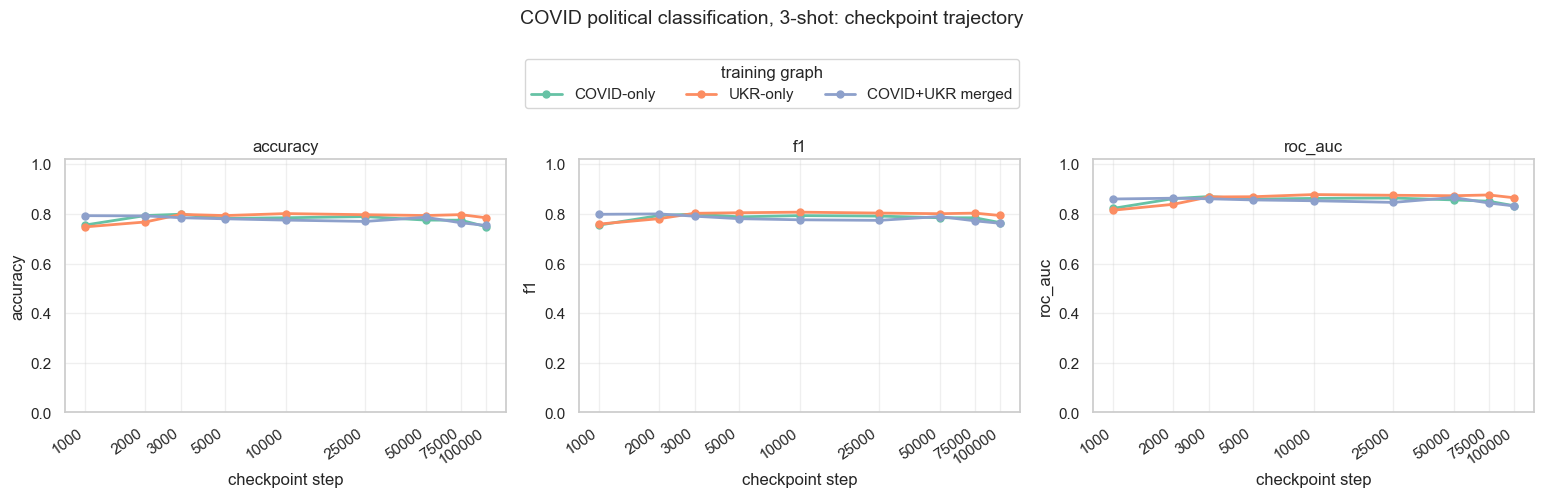

In [3]:
palette = dict(zip(TRAINING_ORDER, sns.color_palette("Set2", n_colors=len(TRAINING_ORDER))))

fig, axes = plt.subplots(1, len(METRICS), figsize=(5.2 * len(METRICS), 4.2), sharex=True)
if len(METRICS) == 1:
    axes = [axes]

for ax, metric in zip(axes, METRICS):
    for training_graph in TRAINING_ORDER:
        line = df[df["training_graph"].astype(str) == training_graph].sort_values("step")
        ax.plot(
            line["step"],
            line[metric],
            marker="o",
            linewidth=2,
            markersize=5,
            color=palette[training_graph],
            label=TRAINING_LABELS[training_graph],
        )
    ax.set_title(metric)
    ax.set_xlabel("checkpoint step")
    ax.set_ylabel(metric)
    ax.set_ylim(0, 1.02)
    ax.set_xscale("symlog", linthresh=1000)
    ax.set_xticks([step for step in REQUESTED_STEPS if step in present_steps])
    ax.set_xticklabels([str(step) for step in REQUESTED_STEPS if step in present_steps], rotation=35, ha="right")
    ax.grid(True, alpha=0.3)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, title="training graph", loc="upper center", ncol=len(labels), bbox_to_anchor=(0.5, 1.08))
fig.suptitle("COVID political classification, 3-shot: checkpoint trajectory", y=1.18, fontsize=14)
fig.tight_layout()
plt.show()

In [4]:
# Best checkpoint per training graph and metric.
best_rows = []
for metric in METRICS:
    idx = df.groupby("training_graph", observed=True)[metric].idxmax()
    best = df.loc[idx, ["training_label", "step", metric]].copy()
    best["metric"] = metric
    best = best.rename(columns={metric: "value"})
    best_rows.append(best)

best_table = pd.concat(best_rows, ignore_index=True)
display(best_table[["metric", "training_label", "step", "value"]].sort_values(["metric", "training_label"]))

,metric,training_label,step,value
2,accuracy,COVID+UKR merged,1000,0.793000
0,accuracy,COVID-only,3000,0.798750
1,accuracy,UKR-only,10000,0.801417
5,f1,COVID+UKR merged,2000,0.800032
3,f1,COVID-only,3000,0.799302
4,f1,UKR-only,10000,0.807123
8,roc_auc,COVID+UKR merged,50000,0.866419
6,roc_auc,COVID-only,3000,0.870043
7,roc_auc,UKR-only,10000,0.878033


In [5]:
# Wide table for inspecting exact values.
wide = df.pivot_table(
    index="step",
    columns="training_label",
    values=METRICS,
    observed=True,
).sort_index()
display(wide)

accuracy                                    f1  \
training_label COVID+UKR merged COVID-only  UKR-only COVID+UKR merged   
step                                                                    
1000                   0.793000   0.755333  0.747833         0.798507   
2000                   0.792083   0.793500  0.767583         0.800032   
3000                   0.784667   0.798750  0.798083         0.790769   
5000                   0.780333   0.781833  0.793333         0.780772   
10000                  0.775083   0.784583  0.801417         0.776369   
25000                  0.769833   0.789167  0.796833         0.774125   
50000                  0.786500   0.775167  0.793583         0.789482   
75000                  0.764250   0.774750  0.797083         0.772130   
100000                 0.753750   0.748667  0.784583         0.762326   

                                             roc_auc                       
training_label COVID-only  UKR-only COVID+UKR merged COVID-only  UKR-only  
step                                                                       
1000             0.755048  0.759153         0.860148   0.822374  0.814988  
2000             0.793775  0.780997         0.863370   0.861741  0.838828  
3000             0.799302  0.802575         0.861049   0.870043  0.868432  
5000             0.788325  0.804755         0.856369   0.859839  0.869325  
10000            0.793250  0.807123         0.853096   0.862566  0.878033  
25000            0.791289  0.803482         0.846523   0.864046  0.875188  
50000            0.784574  0.800900         0.866419   0.856546  0.873323  
75000            0.784501  0.803232         0.843860   0.851143  0.876447  
100000           0.765109  0.793679         0.832365   0.832994  0.865177